# CAPSTONE PROJECT: BOOKS RECOMMENDER SYSTEM

Need to upload data/merged_df.csv to run

What we will cover in this Notebook:

- Load the merged_df from our previous notebook                       
- Build Book Embeddings                                                 
- Genre Labels (Fiction / Nonfiction)                                   
- Sentiment / Tone  
- Vector Search
- Buid Gradio dashboard                                                   
                          


## Set up and Load

In [17]:
import pandas as pd
import numpy as np
import torch
import faiss
import re
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt

In [18]:
merged_df = pd.read_csv('../data/merged_df.csv')

# Embeddings — one row per book (desc + review separately)

In [19]:
# Pick longest description per book (most informative)
desc_pick = (
    merged_df.assign(_len=merged_df['cleaned_description'].astype(str).str.len())
             .sort_values(['book_id','_len'], ascending=[True, False])
             .drop_duplicates('book_id')
             [['book_id','title','author_name','image_url','cleaned_description']]
             .rename(columns={'cleaned_description':'best_desc'})
             .reset_index(drop=True)
)

# Encoder
device = "cuda" if torch.cuda.is_available() else "cpu"
embedder = SentenceTransformer("all-MiniLM-L6-v2", device=device)

# Description embeddings
desc_vecs = embedder.encode(
    desc_pick['best_desc'].fillna("").tolist(),
    batch_size=128 if device=="cuda" else 32,
    show_progress_bar=True,
    convert_to_numpy=True
)
desc_vecs = normalize(desc_vecs).astype('float32')


Batches:   0%|          | 0/169 [00:00<?, ?it/s]

In [20]:
# Review embeddings: sample up to N reviews per book, batch-encode once, mean per book
N_PER_BOOK = 20

reviews_subset = (
    merged_df.loc[merged_df['cleaned_review'].notna(), ['book_id','cleaned_review']]
    .groupby('book_id', group_keys=False)
    .apply(lambda g: g.sample(min(N_PER_BOOK, len(g)), random_state=42))
    .reset_index(drop=True)
)

review_texts = reviews_subset['cleaned_review'].astype(str).tolist()
review_embs = embedder.encode(
    review_texts,
    batch_size=128 if device=="cuda" else 32,
    show_progress_bar=True,
    convert_to_numpy=True
)

reviews_subset['_emb'] = list(review_embs)

book_rev_vecs = (
    reviews_subset.groupby('book_id')['_emb']
    .apply(lambda v: np.mean(np.vstack(v), axis=0))
).to_dict()

# Align review vectors to desc_pick order; fallback to desc vec if none
rev_vecs = []
for bid, dvec in zip(desc_pick['book_id'], desc_vecs):
    v = book_rev_vecs.get(bid)
    rev_vecs.append(v if v is not None else dvec)
rev_vecs = normalize(np.vstack(rev_vecs)).astype('float32')


/var/folders/cy/f_z2j2b90rl7q8vz6jzfv__00000gn/T/ipykernel_50099/757583108.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(N_PER_BOOK, len(g)), random_state=42))


Batches:   0%|          | 0/252 [00:00<?, ?it/s]

In [21]:
# Final books table
books = desc_pick.copy()
books['desc_embedding'] = list(desc_vecs)
books['review_embedding'] = list(rev_vecs)

print(books.shape)
books.head(3)


(5383, 7)


,book_id,title,author_name,image_url,best_desc,desc_embedding,review_embedding
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling,https://images.gr-assets.com/books/1361039191m...,the war against voldemort is not going well: e...,"[-0.057128213, 0.036216136, 0.049336873, -0.02...","[-0.043089155, -0.023724705, 0.089977205, 0.02..."
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling,https://images.gr-assets.com/books/1507396732m...,harry potter is due to start his fifth year at...,"[-0.034554914, -0.0210186, 0.037539426, 0.0415...","[-0.069765255, -0.034240317, 0.028165346, 0.05..."
2,3,Harry Potter and the Sorcerer's Stone (Harry P...,J.K. Rowling,https://images.gr-assets.com/books/1474154022m...,harry potter's life is miserable. his parents ...,"[-0.024627928, 0.036633197, 0.035225805, 0.021...","[-0.046894964, -0.0479641, 0.039935615, 0.0323..."


# Genre classification (Fiction / Nonfiction)
- we will use Heuristic genre for labeling/filtering
- Heuristic (gated, robust)

In [22]:
# Strong vs theme keywords; gated so themes count only if a strong cue exists
NF_STRONG = {
    'memoir','biography','autobiography','nonfiction','non-fiction','true story',
    'textbook','case study','case studies','manual','report','reference',
    'journalism','essays','guide','primer','documentary'
}
NF_THEMES = {
    'history','politics','economics','business','finance','marketing','management',
    'entrepreneurship','science','physics','chemistry','biology','astronomy','neuroscience','ai',
    'mathematics','data','psychology','cognitive','mental health','therapy','addiction',
    'health','nutrition','fitness','diet','yoga','longevity',
    'philosophy','ethics','existentialism','stoicism','metaphysics',
    'religion','christianity','buddhism','islam','meditation',
    'education','pedagogy','learning techniques','homeschooling',
    'environment','climate change','conservation','renewable energy',
    'arts','music','painting','filmmaking','photography','research',
    'true crime','serial killers','cold cases','investigations',
    'travel','exploration','backpacking','cultural immersion',
    'social justice','geopolitics','democracy','activism',
    'museum','poetry','diary','letters','cookbook','cuisine','language','caregiving'
}
FIC_STRONG = {
    'novel','novella','short stories','fiction','historical fiction','literary fiction',
    'science fiction','sci-fi','fantasy','urban fantasy','romance','mystery','thriller',
    'horror','dystopian','space opera','retelling','fairy tale'
}
FIC_THEMES = {
    'witch','wizard','magic','dragons','elves','wizards','quest','mythical','sword and sorcery','sorcery',
    'paranormal','supernatural','ghosts','haunted','demon','vampire','aliens','cyberpunk','time travel',
    'detective','crime','murder','suspense','clues','chronicles','saga','adventure','journey','treasure hunt',
    'love','passion','heartbreak','marriage','enemies-to-lovers',
    'ya','young adult','coming-of-age','teenage','school','first love',
    'victorian','renaissance'
}

def _compile_phrase(p):
    p = re.escape(p).replace(r'\ ', r'[\s\-_]+')
    return re.compile(rf'(?<!\w){p}(?!\w)', flags=re.I)

NF_STRONG_PAT = {k:_compile_phrase(k) for k in NF_STRONG}
NF_THEME_PAT  = {k:_compile_phrase(k) for k in NF_THEMES}
FIC_STRONG_PAT= {k:_compile_phrase(k) for k in FIC_STRONG}
FIC_THEME_PAT = {k:_compile_phrase(k) for k in FIC_THEMES}

def _norm(t):
    t = (t or "").lower()
    t = re.sub(r'[\-_]+',' ', t)
    return re.sub(r'\s+',' ', t).strip()

def _side_score(text, strong_pat, theme_pat, w_strong=3.0, w_theme=1.0, gated=True):
    s_hits = sum(len(p.findall(text)) for p in strong_pat.values())
    t_hits = sum(len(p.findall(text)) for p in theme_pat.values())
    if gated and s_hits == 0:
        w_theme = 0.0
    return s_hits*w_strong + t_hits*w_theme

def guess_genre(title, desc, tie_bias="Fiction"):
    text = _norm(f"{title} {desc}")
    nf = _side_score(text, NF_STRONG_PAT, NF_THEME_PAT)
    fic = _side_score(text, FIC_STRONG_PAT, FIC_THEME_PAT)
    if ' novel ' in f" {text} " and fic >= nf: return "Fiction"
    if nf > fic: return "Nonfiction"
    if fic > nf: return "Fiction"
    return tie_bias

books['genre'] = books.apply(lambda r: guess_genre(r['title'], r['best_desc']), axis=1)
books['genre'].value_counts()


genre
Fiction       5271
Nonfiction     112
Name: count, dtype: int64

### PCA Scatter Plot of Book Embeddings by Genre (PCA)

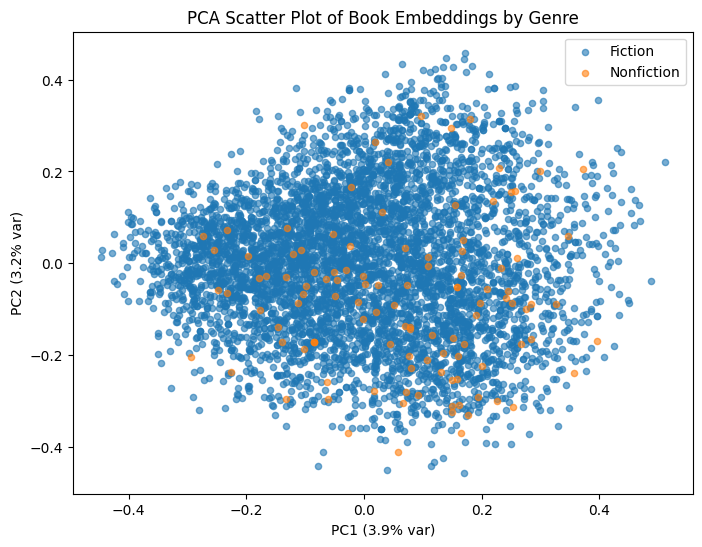

In [23]:
from sklearn.decomposition import PCA

labels = books['genre']

# Get embeddings matrix
X_emb = np.vstack(books['desc_embedding'].values)

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_emb)

# Plot
plt.figure(figsize=(8, 6))
for genre, color in zip(['Fiction', 'Nonfiction'], ['tab:blue', 'tab:orange']):
    idx = labels == genre
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=genre, alpha=0.6, s=20, c=color)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA Scatter Plot of Book Embeddings by Genre")
plt.legend()
plt.show()


## Build a classification Model

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

# Features = description embeddings
X = np.vstack(books['desc_embedding'].values)

# Labels = genre
y = books['genre'].values

# Compute class weights for imbalance
classes = np.array(['Fiction', 'Nonfiction'])
class_weights = dict(zip(
    classes,
    compute_class_weight(class_weight='balanced', classes=classes, y=y)
))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train Logistic Regression with class weights
clf = LogisticRegression(
    class_weight=class_weights,
    max_iter=200,
    solver='liblinear'
)
clf.fit(X_train, y_train)

# Predictions and report
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     Fiction       0.99      0.89      0.94      1055
  Nonfiction       0.10      0.64      0.18        22

    accuracy                           0.88      1077
   macro avg       0.55      0.76      0.56      1077
weighted avg       0.97      0.88      0.92      1077



## Tune the decision threshold

In [25]:
import numpy as np
from sklearn.metrics import classification_report, precision_recall_curve

# Get Nonfiction probability
probs = clf.predict_proba(X_test)[:, list(clf.classes_).index('Nonfiction')]

# Sweep thresholds and pick one that improves Nonfiction F1 (or precision)
prec, rec, thr = precision_recall_curve((y_test=='Nonfiction').astype(int), probs)

f1 = (2 * prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1)
best_thr = thr[best_idx]
best_thr


np.float64(0.5221299997697185)

In [26]:
y_pred_thr = np.where(probs >= best_thr, 'Nonfiction', 'Fiction')
print(classification_report(y_test, y_pred_thr))


              precision    recall  f1-score   support

     Fiction       0.99      0.90      0.94      1055
  Nonfiction       0.11      0.59      0.19        22

    accuracy                           0.90      1077
   macro avg       0.55      0.75      0.57      1077
weighted avg       0.97      0.90      0.93      1077



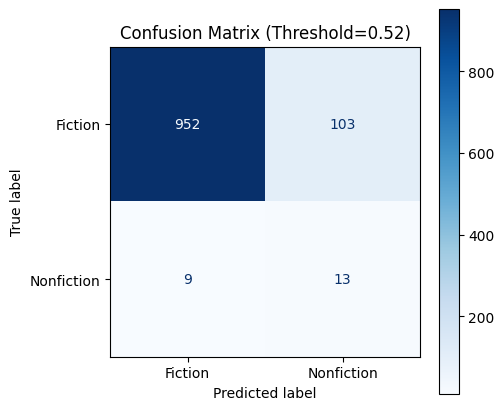

In [27]:
# Generate the confusion matrix using the tuned threshold predictions
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use thresholded predictions
cm = confusion_matrix(y_test, y_pred_thr, labels=['Fiction', 'Nonfiction'])

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fiction', 'Nonfiction'])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix (Threshold={best_thr:.2f})")
plt.show()

# Sentiment / tone from reviews

In [28]:
# Build short tone text per book (concat up to 3 mid-length reviews; fallback to desc)
def make_tone_text(df, n_per_book=3, min_words=20, max_words=100):
    tmp = (df.assign(wc=df['cleaned_review'].astype(str).str.split().str.len())
             .query('wc >= @min_words and wc <= @max_words')
             .groupby('book_id')['cleaned_review']
             .apply(lambda s: ' '.join(s.head(n_per_book))))
    return tmp

tone_snips = make_tone_text(merged_df, n_per_book=3)
books = books.merge(tone_snips.rename('tone_text'), on='book_id', how='left')
books['tone_text'] = books['tone_text'].fillna(books['best_desc'].astype(str).str.split().str[:100].str.join(' '))


In [29]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tok  = AutoTokenizer.from_pretrained(model_name, use_fast=True)
mdl  = AutoModelForSequenceClassification.from_pretrained(model_name)
device_idx = 0 if torch.cuda.is_available() else -1
sent = TextClassificationPipeline(model=mdl, tokenizer=tok, device=device_idx)

# De-duplicate to speed up
u_texts, inv_idx = np.unique(books['tone_text'].fillna("").values, return_inverse=True)

labels, scores = [], []
BATCH, MAX_LEN = (128, 128) if device_idx==0 else (32, 128)
for i in range(0, len(u_texts), BATCH):
    out = sent(u_texts[i:i+BATCH].tolist(), truncation=True, max_length=MAX_LEN)
    if isinstance(out, dict): out = [out]
    for o in out:
        labels.append(o['label'].lower()); scores.append(float(o['score']))

books['sentiment_label'] = [labels[j] for j in inv_idx]
books['sentiment_score'] = [scores[j] for j in inv_idx]

def tone_bucket(lbl, s, pos=0.7, neg=0.7):
    if lbl == 'positive' and s >= pos: return 'uplifting'
    if lbl == 'negative' and s >= neg: return 'dark'
    return 'mixed'

books['tone'] = [tone_bucket(l, s) for l,s in zip(books['sentiment_label'], books['sentiment_score'])]
books[['genre','tone']].value_counts().head()


Device set to use cpu


genre       tone     
Fiction     uplifting    3448
            dark         1628
            mixed         195
Nonfiction  uplifting      90
            dark           19
Name: count, dtype: int64

# Vector search (FAISS) + fusion (topic↔vibe)



In [30]:
D_mat = np.vstack(books['desc_embedding'].values).astype('float32')
R_mat = np.vstack(books['review_embedding'].values).astype('float32')

D_mat = normalize(D_mat).astype('float32')
R_mat = normalize(R_mat).astype('float32')

dim = D_mat.shape[1]
idx_desc = faiss.IndexFlatIP(dim); idx_desc.add(D_mat)
idx_rev  = faiss.IndexFlatIP(dim); idx_rev.add(R_mat)

def encode_query(q):
    v = embedder.encode([q], convert_to_numpy=True, show_progress_bar=False)
    return normalize(v).astype('float32')

def fused_search(query, top_k=10, alpha=0.75, overfetch=50):
    q = encode_query(query)
    K = min(overfetch, D_mat.shape[0])
    Sd, Id = idx_desc.search(q, K)
    Sr, Ir = idx_rev.search(q, K)
    scores = {}
    for s,i in zip(Sd[0], Id[0]): scores[i] = scores.get(i, 0) + alpha*s
    for s,i in zip(Sr[0], Ir[0]): scores[i] = scores.get(i, 0) + (1-alpha)*s
    ranked = sorted(scores.items(), key=lambda x: -x[1])[:top_k]
    rows   = [i for i,_ in ranked]; scs = [s for _,s in ranked]
    return rows, scs


# Gradio app

In [34]:
import gradio as gr

def format_card(i):
    row = books.iloc[i]
    title = f"**{row['title']}**"
    author = f"{row['author_name']}"
    meta  = f"**Genre:** {row.get('genre','?')} | **Tone:** {row.get('tone','?')}"
    desc  = (str(row['best_desc'])[:400] + '...') if isinstance(row['best_desc'], str) else ''
    body  = f"{title}\n\n{author}\n\n{meta}\n\n{desc}"
    return body, row.get('image_url', None)

def recommend(query, alpha, top_k, genre_filter, tone_filter):
    if not query or not str(query).strip():
        return "_Enter a query_", []
    rows, _ = fused_search(query, top_k=int(top_k), alpha=float(alpha), overfetch=50)

    # apply filters
    out = []
    for r in rows:
        g = books.iloc[r].get('genre', None)
        t = books.iloc[r].get('tone', None)
        if (genre_filter=="Any" or g==genre_filter) and (tone_filter=="Any" or t==tone_filter):
            out.append(r)

    cards, imgs = [], []
    for r in out[:int(top_k)]:
        c, img = format_card(r)
        cards.append(c); imgs.append((img, ""))
    return ("\n\n---\n\n".join(cards) if cards else "_No results_"), imgs

with gr.Blocks() as demo:
    gr.Markdown("# Book Recommender — Team 11")
    q = gr.Textbox(label="Describe a book, vibe, themes, or paste a title", placeholder="e.g., tender coming-of-age memoir with humor")
    with gr.Row():
        a = gr.Slider(0.0, 1.0, value=0.75, step=0.05, label="Recommender Emphasis (Topic↔Vibe)")
        k = gr.Slider(5, 30, value=10, step=1, label="Results")
    with gr.Row():
        gsel = gr.Dropdown(["Any","Fiction","Nonfiction"], value="Any", label="Genre")
        tsel = gr.Dropdown(["Any","uplifting","dark","mixed"], value="Any", label="Tone")
    res = gr.Markdown()
    gal = gr.Gallery(label="Covers", columns=5, height=220)
    btn = gr.Button("Recommend")
    btn.click(recommend, inputs=[q, a, k, gsel, tsel], outputs=[res, gal])

demo.launch()


* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


# Export the lightweight artifacts to use in app.py file

In [ ]:
import numpy as np
import pandas as pd

# Embedding matrices (float32, already L2-normalized in our pipeline)
D_mat = np.vstack(books['desc_embedding'].values).astype('float32')
R_mat = np.vstack(books['review_embedding'].values).astype('float32')

#  Minimal metadata the app needs
books_meta = books[['book_id','title','author_name','image_url','best_desc','genre','tone']].copy()

# Save files
np.save("../data/desc_emb.npy", D_mat)
np.save("../data/rev_emb.npy",  R_mat)
books_meta.to_csv("../data/books_meta.csv", index=False)

print("Saved: desc_emb.npy, rev_emb.npy, books_meta.csv")
print("Shapes:", D_mat.shape, R_mat.shape, len(books_meta))


Saved: desc_emb.npy, rev_emb.npy, books_meta.csv
Shapes: (5383, 384) (5383, 384) 5383
